# **Metal Surface Defect Fine Segmentation**
This notebook demonstrates **fine semantic segmentation** on the Severstal Steel Defect dataset.
Instead of classifying the entire image, this model predicts precisely which pixels belong to which defect class.

It leverages bleeding-edge architectures and libraries:
1. **Model**: `segmentation_models_pytorch` with `FPN` and a **SegFormer MiT-B2** backbone.
2. **Data Augmentation**: `albumentations` for synchronized spatial image + mask transforms.
3. **Loss Function**: Combined `DiceLoss` + `FocalLoss` for highly imbalanced segmentation classes.


### **0. Install Dependencies**


In [18]:
!pip install segmentation-models-pytorch albumentations gdown timm


### **1. Imports and Setup**


In [19]:
import os
import random
import zipfile

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Lock Random Seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


Using device: cuda


### **2. Data Downloading & Splitting**


In [20]:
# Define constants
TRAIN_CSV = 'train_split.csv'
VAL_CSV   = 'val_split.csv'
TEST_CSV  = 'test_split.csv'
IMG_DIR   = 'train_images'

def download_data():
    import gdown
    from sklearn.model_selection import train_test_split

    ZIP_PATH = 'data.zip'
    FILE_ID  = '1jVWUmYdMmOCiIRcw8HPCw6rhNhRFS6sv'
    GITHUB_CSV_URL = "https://raw.githubusercontent.com/blancjh/steel-defect-classification/main/data/steel-defect-dataset.csv"

    # Images
    if not os.path.exists(IMG_DIR):
        print("Downloading images...")
        gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
        os.makedirs(IMG_DIR, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(IMG_DIR)
        os.remove(ZIP_PATH)

    # CSVs
    if not all(os.path.exists(p) for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]):
        print("Downloading and splitting CSV...")
        df = pd.read_csv(GITHUB_CSV_URL)
        if 'ImageId_ClassId' in df.columns:
            df['BaseImageId'] = df['ImageId_ClassId'].apply(lambda x: str(x).split('_')[0])
        else:
            df['BaseImageId'] = df['ImageId']

        unique_images = df['BaseImageId'].unique()
        train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)
        val_imgs,   test_imgs = train_test_split(temp_imgs,     test_size=0.5, random_state=42)

        df[df['BaseImageId'].isin(train_imgs)].drop(columns=['BaseImageId']).to_csv(TRAIN_CSV, index=False)
        df[df['BaseImageId'].isin(val_imgs)].drop(columns=['BaseImageId']).to_csv(VAL_CSV,   index=False)
        df[df['BaseImageId'].isin(test_imgs)].drop(columns=['BaseImageId']).to_csv(TEST_CSV,  index=False)

download_data()


### **3. RLE Decoding**
The Kaggle dataset provides `EncodedPixels` in Run-Length Encoding. We decode this into binary masks.


In [21]:
def rle2mask(rle, shape=(256, 1600)):
    '''
    rle   : run-length as string formatted (start length)
    shape : (height, width) of array to return
    Returns numpy array, 1 = mask, 0 = background
    '''
    s = rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0::2], s[1::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order='F')  # Kaggle RLE is Fortran-ordered


### **4. Albumentations and PyTorch Dataset**


In [22]:
IMG_HEIGHT  = 256
IMG_WIDTH   = 800
NUM_CLASSES = 4

train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, shift_limit=0.1, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),   # <-- ensures mask is also transposed to (C, H, W)
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])


class SteelDefectSegDataset(Dataset):
    def __init__(self, csv_path, img_dir, transforms):
        self.df = pd.read_csv(csv_path)
        self.img_dir    = img_dir
        self.transforms = transforms

        # Parse ImageId / ClassId
        if 'ImageId_ClassId' in self.df.columns:
            self.df['ImageId'] = self.df['ImageId_ClassId'].apply(lambda x: str(x).split('_')[0])
            self.df['ClassId'] = self.df['ImageId_ClassId'].apply(lambda x: int(str(x).split('_')[1]))

        self.orig_shape    = (256, 1600)
        self.unique_images = list(self.df['ImageId'].unique())

        # Pre-group defects by image for fast lookup
        self.img_to_defects = {}
        for _, row in self.df.dropna(subset=['EncodedPixels']).iterrows():
            img_id = row['ImageId']
            cls    = int(row['ClassId'])
            rle    = row['EncodedPixels']
            self.img_to_defects.setdefault(img_id, []).append((cls, rle))

    def __len__(self):
        return len(self.unique_images)

    def __getitem__(self, idx):
        img_name = self.unique_images[idx]

        # Resolve image path (handles nested extraction folder)
        img_path = os.path.join(self.img_dir, img_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir, 'train_images', img_name)

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        
        # Build multi-channel mask  (H, W, NUM_CLASSES)
        mask = np.zeros((*self.orig_shape, NUM_CLASSES), dtype=np.float32)
        for cls, rle in self.img_to_defects.get(img_name, []):
            mask[:, :, cls - 1] = rle2mask(rle, shape=self.orig_shape)
        
        # Albumentations applies identical spatial transforms to image AND mask
        augmented = self.transforms(image=image, mask=mask)

        # With transpose_mask=True the mask is already (C, H, W) — same layout as the image
        return augmented['image'], augmented['mask']


/home/blancjh/metal-defect-classification/.mdc-venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [23]:
BATCH_SIZE = 4
workers    = 2

train_ds = SteelDefectSegDataset(TRAIN_CSV, IMG_DIR, transforms=train_transform)
val_ds   = SteelDefectSegDataset(VAL_CSV,   IMG_DIR, transforms=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=workers, pin_memory=True)

# Quick sanity check — shapes must be (C, H, W) for both image and mask
img, msk = train_ds[0]
print(f"Train sets : {len(train_ds)}")
print(f"Val sets   : {len(val_ds)}")
print(f"Image shape: {img.shape}  |  Mask shape: {msk.shape}")


Train sets : 5332
Val sets   : 667
Image shape: torch.Size([3, 256, 800])  |  Mask shape: torch.Size([4, 256, 800])


### **5. Model Definition**
Using FPN with the SegFormer **MiT-B2** encoder — a modern Vision Transformer backbone
that is natively supported by `segmentation_models_pytorch`.


In [24]:
model = smp.FPN(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,       # raw logits — loss function handles sigmoid
)
model = model.to(device)

# Combined loss: Dice (boundary-aware, IoU-optimising) + Focal (handles class imbalance)
dice_loss_fn  = smp.losses.DiceLoss(mode='multilabel', from_logits=True)
focal_loss_fn = smp.losses.FocalLoss(mode='multilabel')

def mixed_loss(y_pred, y_true):
    return dice_loss_fn(y_pred, y_true) + focal_loss_fn(y_pred, y_true)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

# Mixed-precision scaler (safe on CPU too — just becomes a no-op)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))


### **6. Training Loop**


In [25]:
EPOCHS    = 30
THRESHOLD = 0.5

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            logits = model(images)
            loss   = mixed_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_loss = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device)

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                logits = model(images)
                loss   = mixed_loss(logits, masks)

            val_loss += loss.item()

            preds = (torch.sigmoid(logits) > THRESHOLD).long()
            tp, fp, fn, tn = smp.metrics.get_stats(
                preds, masks.long(), mode='multilabel', threshold=None
            )
            val_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction='micro').item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_iou    /= len(val_loader)

    scheduler.step()

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] — "
        f"Train Loss: {train_loss:.4f} — "
        f"Val Loss: {val_loss:.4f} — "
        f"Val IoU: {val_iou:.4f}"
    )


Epoch [ 1/30] — Train Loss: 0.2839 — Val Loss: 0.2171 — Val IoU: 0.5333
Epoch [ 2/30] — Train Loss: 0.2269 — Val Loss: 0.2171 — Val IoU: 0.5197
Epoch [ 3/30] — Train Loss: 0.2131 — Val Loss: 0.1987 — Val IoU: 0.5659
Epoch [ 4/30] — Train Loss: 0.2007 — Val Loss: 0.2001 — Val IoU: 0.5478
Epoch [ 5/30] — Train Loss: 0.1970 — Val Loss: 0.1976 — Val IoU: 0.5669
Epoch [ 6/30] — Train Loss: 0.1961 — Val Loss: 0.1949 — Val IoU: 0.5595
Epoch [ 7/30] — Train Loss: 0.1862 — Val Loss: 0.1874 — Val IoU: 0.5727
Epoch [ 8/30] — Train Loss: 0.1829 — Val Loss: 0.1932 — Val IoU: 0.5710
Epoch [ 9/30] — Train Loss: 0.1768 — Val Loss: 0.1827 — Val IoU: 0.5813
Epoch [10/30] — Train Loss: 0.1726 — Val Loss: 0.1859 — Val IoU: 0.5794
Epoch [11/30] — Train Loss: 0.1698 — Val Loss: 0.1844 — Val IoU: 0.5807
Epoch [12/30] — Train Loss: 0.1662 — Val Loss: 0.1792 — Val IoU: 0.5914
Epoch [13/30] — Train Loss: 0.1615 — Val Loss: 0.1731 — Val IoU: 0.6001
Epoch [14/30] — Train Loss: 0.1546 — Val Loss: 0.1708 — Val IoU:

### **7. Visualization of Results**
Each defect class is rendered with a distinct colour overlay:
- **Class 1** → Red
- **Class 2** → Green
- **Class 3** → Blue
- **Class 4** → Yellow


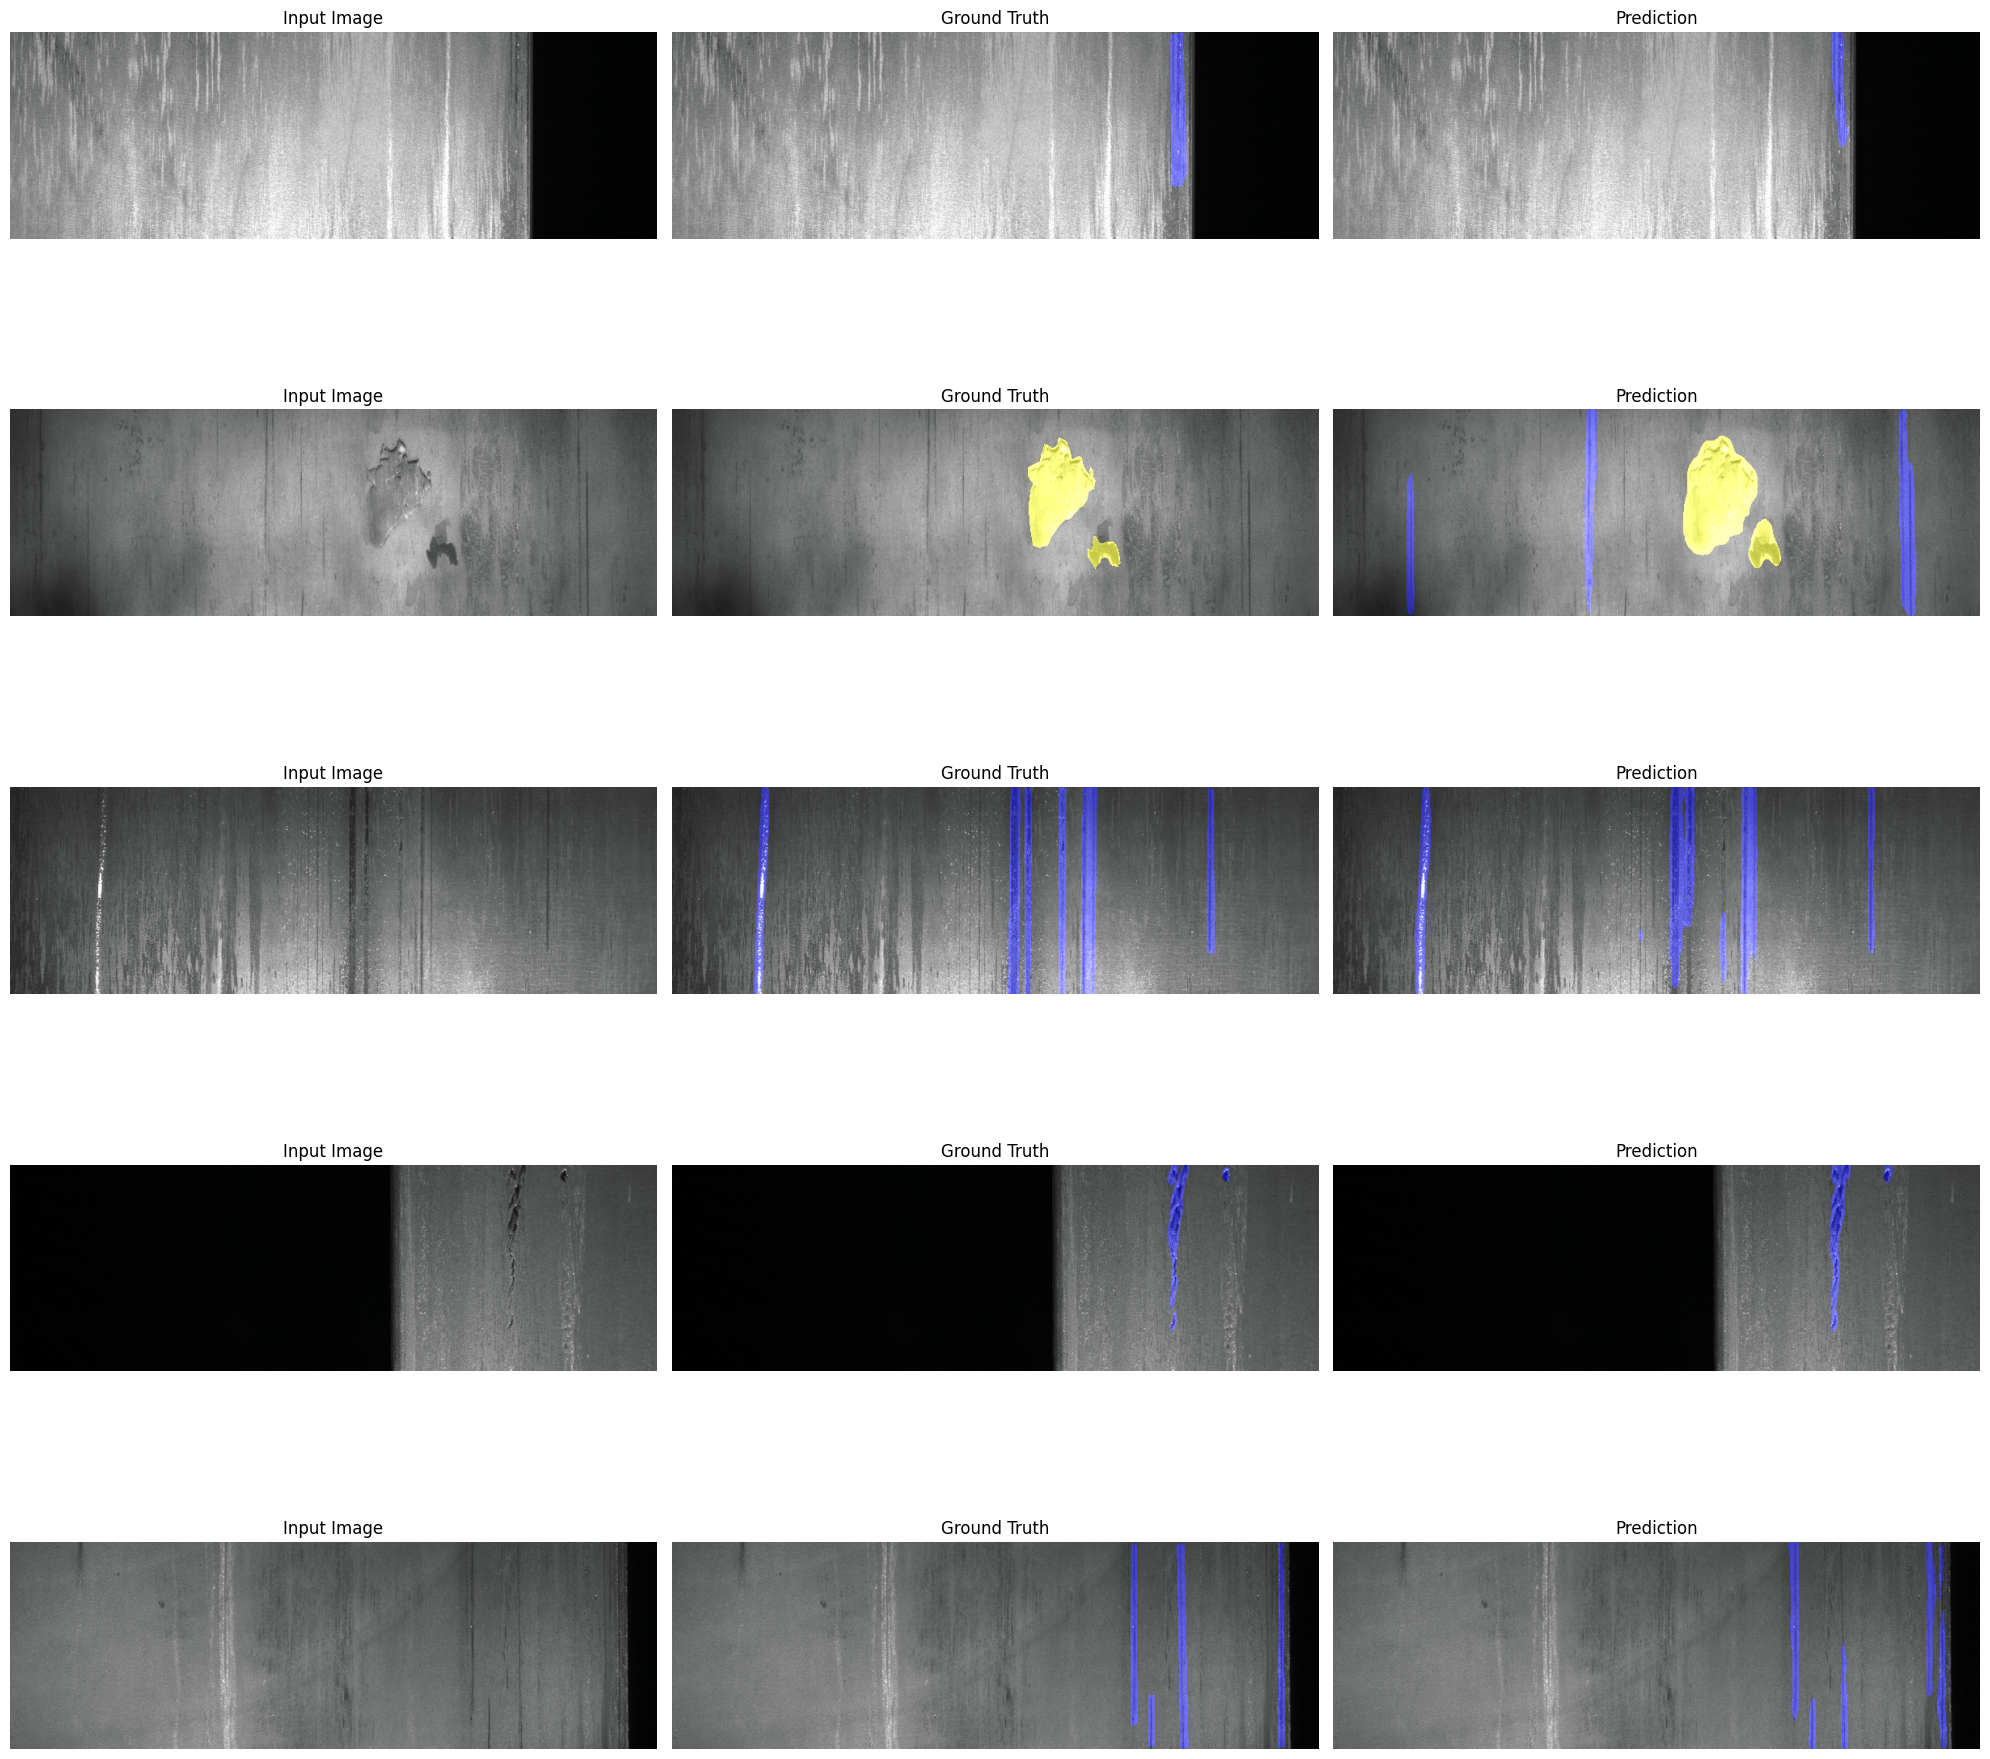

In [26]:
def visualize_predictions(model, dataset, num_samples=3):
    model.eval()

    COLORS = [
        (255, 0,   0  ),   # Class 1 — Red
        (0,   255, 0  ),   # Class 2 — Green
        (0,   0,   255),   # Class 3 — Blue
        (255, 255, 0  ),   # Class 4 — Yellow
    ]

    # Pick random samples that actually contain defects
    defect_indices = [
        dataset.unique_images.index(img)
        for img in dataset.img_to_defects
        if img in dataset.unique_images
    ]
    selected = random.sample(defect_indices, min(num_samples, len(defect_indices)))

    fig, axes = plt.subplots(len(selected), 3, figsize=(20, 4 * len(selected)))
    if len(selected) == 1:
        axes = [axes]

    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

    def overlay(img, multi_mask, colors):
        out = img.copy()
        for c in range(multi_mask.shape[0]):
            m = multi_mask[c]
            if m.max() > 0:
                coloured = np.zeros_like(img)
                for ch in range(3):
                    coloured[:, :, ch] = m * colors[c][ch]
                out = cv2.addWeighted(out, 1.0, coloured, 0.5, 0)
        return out

    with torch.no_grad():
        for i, idx in enumerate(selected):
            img_t, mask_t = dataset[idx]
            logits = model(img_t.unsqueeze(0).to(device))
            pred   = (torch.sigmoid(logits[0]) > THRESHOLD).cpu().numpy().astype(np.uint8)

            img_np  = np.clip((img_t.numpy() * std + mean) * 255, 0, 255).astype(np.uint8).transpose(1, 2, 0)
            mask_np = mask_t.numpy().astype(np.uint8)

            axes[i][0].imshow(img_np);           axes[i][0].set_title("Input Image");        axes[i][0].axis('off')
            axes[i][1].imshow(overlay(img_np, mask_np, COLORS)); axes[i][1].set_title("Ground Truth"); axes[i][1].axis('off')
            axes[i][2].imshow(overlay(img_np, pred,    COLORS)); axes[i][2].set_title("Prediction");   axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, num_samples=5)


In [27]:
# Save the model weights after training completes
torch.save(model.state_dict(), 'steel_defect_model.pth')
print("Model saved successfully!")


Model saved successfully!
